In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 29.4 MB/s eta 0:00:00


In [2]:
 from qutip import *
 import numpy as np
 import matplotlib.pyplot as plt
 import math
 import cmath

In [3]:
Q = Qobj()

In [4]:
Qobj([[1],[2],[3],[4],[5]])

Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [2.]
 [3.]
 [4.]
 [5.]]

In [5]:
basis(5, 4)

Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [1.]]

In [6]:
bs1 = []
for i in range(3):
  bs1.append(basis(3,2-i))

print(bs1)

[Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]], Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]], Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]]]


In [7]:
bs = []

for i in range(27):
    bs.append(basis(27,(26-i)))

print(bs[2])

Quantum object: dims=[[27], [1]], shape=(27, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]]


In [8]:
I3 = 	qeye(3)
print(I3)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dia, isherm=True
Qobj data =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [9]:
density1 = bs1[0].proj()
print(density1)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


In [10]:
density = tensor(density1, density1, density1)
#print(density)

In [11]:
sigma12 = bs1[0]*(bs1[1].dag())
sigma21 = bs1[1]*(bs1[0].dag())
M = sigma12 + sigma21
print(M)
M_squared = M*M

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [12]:
U_pulse_real = math.cos(math.pi/4)*M_squared
U_pulse_imaginary = math.sin(math.pi/4)*M
n = 1j
U_pulse = U_pulse_real - (U_pulse_imaginary)*n
#U_pulse_1 = complex(U_pulse_real.data, U_pulse_imaginary.data)
print(U_pulse)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.        +0.j         0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.j         0.        -0.70710678j]
 [0.        +0.j         0.        -0.70710678j 0.70710678+0.j        ]]


In [13]:
U_pulse_3 = tensor(U_pulse, U_pulse, U_pulse)
#print(U_pulse_3)

In [14]:
J_12 = 10
J_23 = 10
H_dd = J_12*(tensor(sigma12,sigma21,I3) + tensor(sigma21,sigma12,I3)) + J_23*(tensor(I3,sigma12,sigma21) + tensor(I3,sigma21,sigma12))
print(H_dd)

Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0. 

In [15]:
psi0 = U_pulse_3*(tensor(bs1[0],bs1[0],bs1[0]))
print(psi0)

Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.35355339j]
 [-0.35355339+0.j        ]
 [ 0.        +0.j        ]
 [-0.35355339+0.j        ]
 [ 0.        -0.35355339j]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.35355339+0.j        ]
 [ 0.        -0.35355339j]
 [ 0.        +0.j        ]
 [ 0.        -0.35355339j]
 [ 0.35355339+0.j        ]]


In [16]:
times = np.linspace(0, 10, 100)


In [17]:
pt = []
result = mesolve(H_dd, psi0, times, [], [tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)])
pt = result.expect
print(pt)


[array([0.25      +0.00000000e+00j, 0.24999996-2.08166817e-17j,
       0.24999994+3.46944695e-17j, 0.24999987-1.04083409e-16j,
       0.2499991 +1.11022302e-16j, 0.24999863-1.17961196e-16j,
       0.24999815+9.71445147e-17j, 0.24999768-9.02056208e-17j,
       0.2499972 +6.93889390e-17j, 0.24999673-3.46944695e-17j,
       0.24999626+1.73472348e-18j, 0.24999578+5.34511671e-17j,
       0.24999531-8.15320034e-17j, 0.24999484+9.36750677e-17j,
       0.24999435-1.17961196e-16j, 0.24999389+1.17961196e-16j,
       0.24999341-9.71445147e-17j, 0.24999293+9.71445147e-17j,
       0.24999246-1.04083409e-16j, 0.24999198+6.24500451e-17j,
       0.24999151-2.42861287e-17j, 0.24999104-1.21430643e-17j,
       0.24999056+7.65446734e-17j, 0.24999009-1.07552856e-16j,
       0.24998961+1.28369537e-16j, 0.24998914-1.24900090e-16j,
       0.24998867+1.38777878e-16j, 0.24998819-1.45716772e-16j,
       0.24998772+1.11022302e-16j, 0.24998724-1.11022302e-16j,
       0.24998676+6.24500451e-17j, 0.2499863 +0.000000

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.24998, 0.25)

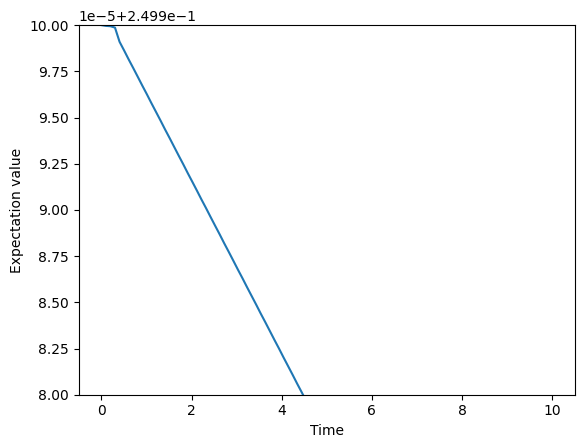

In [18]:
re = -1j
plt.plot(result.times, pt[0])
plt.xlabel('Time')
plt.ylabel('Expectation value')
plt.ylim([0.24998,0.25])

In [19]:
result1 = mesolve(H_dd, psi0, times, [], [tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12)])
result1.expect

[array([0.25      +0.j, 0.12751398+0.j, 0.24014633+0.j, 0.14642834+0.j,
        0.2136918 +0.j, 0.17829268+0.j, 0.17897815+0.j, 0.21305995+0.j,
        0.14695144+0.j, 0.23976683+0.j, 0.1277101 +0.j, 0.24999194+0.j,
        0.12732098+0.j, 0.24051101+0.j, 0.14590642+0.j, 0.21431347+0.j,
        0.17760569+0.j, 0.17965985+0.j, 0.21242304+0.j, 0.14747698+0.j,
        0.2393796 +0.j, 0.12791254+0.j, 0.24997525+0.j, 0.12713526+0.j,
        0.24086888+0.j, 0.14538986+0.j, 0.21493183+0.j, 0.17691994+0.j,
        0.18034248+0.j, 0.21178311+0.j, 0.1480074 +0.j, 0.23898603+0.j,
        0.12812226+0.j, 0.24995091+0.j, 0.12695692+0.j, 0.2412202 +0.j,
        0.14487848+0.j, 0.2155468 +0.j, 0.17623552+0.j, 0.18102596+0.j,
        0.21114022+0.j, 0.14854263+0.j, 0.23858617+0.j, 0.12833923+0.j,
        0.24991893+0.j, 0.126786  +0.j, 0.24156493+0.j, 0.14437233+0.j,
        0.21615831+0.j, 0.17555251+0.j, 0.18171019+0.j, 0.21049448+0.j,
        0.1490826 +0.j, 0.23818007+0.j, 0.12856344+0.j, 0.249879

Text(0, 0.5, 'Expectation value')

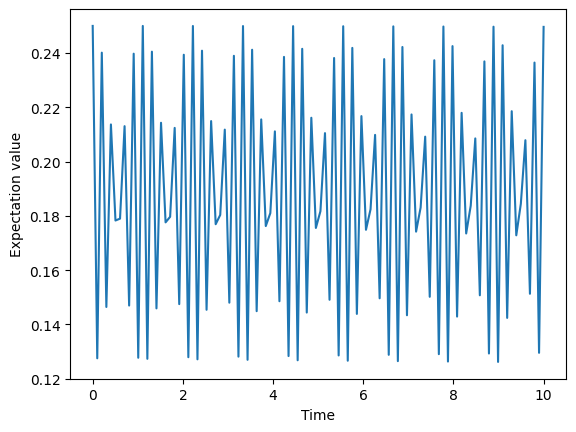

In [20]:
plt.plot(result.times, result1.expect[0])
plt.xlabel('Time')
plt.ylabel('Expectation value')

(-1e-15, 1e-15)

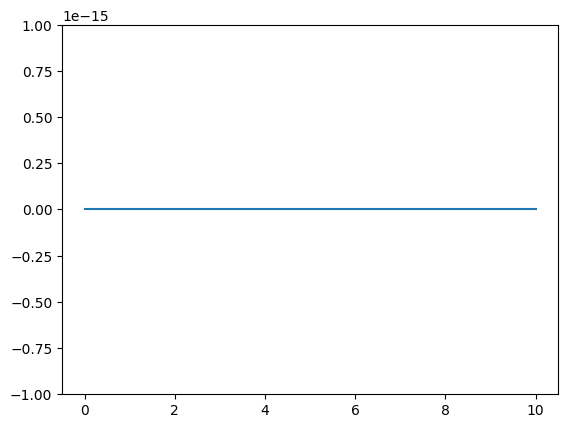

In [21]:
plt.plot(result.times, result1.expect[0]*re)
plt.ylim([-1e-15,1e-15])

In [22]:
result2 = mesolve(H_dd, psi0, times, [], [(tensor(sigma21,I3,I3)*tensor(I3,sigma12,I3))*tensor(I3,I3,sigma21)])
result2.expect

[array([ 0.00000000e+00+0.125j     ,  3.81639165e-17+0.24748596j,
         2.08166817e-17+0.13485358j,  1.24900090e-16+0.22857146j,
         9.71445147e-17+0.16130685j,  8.32667268e-17+0.19670526j,
         5.55111512e-17+0.19601907j,  1.38777878e-17+0.16193657j,
         5.55111512e-17+0.22804436j,  6.93889390e-17+0.13522826j,
         7.28583860e-17+0.24728429j,  1.09287579e-16+0.12500172j,
         1.14491749e-16+0.24767198j,  1.11022302e-16+0.13448124j,
         1.38777878e-16+0.22908511j,  1.80411242e-16+0.16067736j,
         1.38777878e-16+0.19738442j,  1.66533454e-16+0.19532955j,
         1.52655666e-16+0.16256565j,  1.52655666e-16+0.22751099j,
         1.59594560e-16+0.13560767j,  1.11022302e-16+0.24707402j,
         1.58293517e-16+0.12501059j,  1.59594560e-16+0.24784988j,
         1.45716772e-16+0.13411554j,  1.38777878e-16+0.22959384j,
         1.38777878e-16+0.16005117j,  1.24900090e-16+0.19806234j,
         9.71445147e-17+0.1946391j ,  8.32667268e-17+0.16319776j,
         1

In [23]:
result3 = mesolve(H_dd, psi0, times, [], [(tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3))*(tensor(I3,sigma12,I3)*(tensor(sigma21,I3,I3)))])
result3.expect

[array([0.25      , 0.31124295, 0.25492675, 0.30178563, 0.26815275,
        0.28585161, 0.28550814, 0.26846655, 0.30152008, 0.25511167,
        0.31113934, 0.24999769, 0.31133247, 0.25473675, 0.30203832,
        0.26783409, 0.28618727, 0.28515947, 0.26877718, 0.30124948,
        0.25529747, 0.31103029, 0.24999821, 0.31141751, 0.25454998,
        0.30228878, 0.26751709, 0.28652231, 0.28481034, 0.26908931,
        0.30097645, 0.25548643, 0.3109176 , 0.25000256, 0.31149885,
        0.25436649, 0.30253665, 0.26720177, 0.28685669, 0.28446078,
        0.26940292, 0.30070101, 0.25567853, 0.31080128, 0.25001073,
        0.31157648, 0.2541863 , 0.3027819 , 0.26688818, 0.28719038,
        0.28411083, 0.26971796, 0.3004232 , 0.25587375, 0.31068135,
        0.25002272, 0.31165039, 0.25400943, 0.3030245 , 0.26657637,
        0.28752332, 0.28376054, 0.27003441, 0.30014305, 0.25607206,
        0.31055783, 0.25003852, 0.31172058, 0.25383589, 0.30326441,
        0.26626636, 0.28785547, 0.28340996, 0.27

Text(0, 0.5, 'Expectation value')

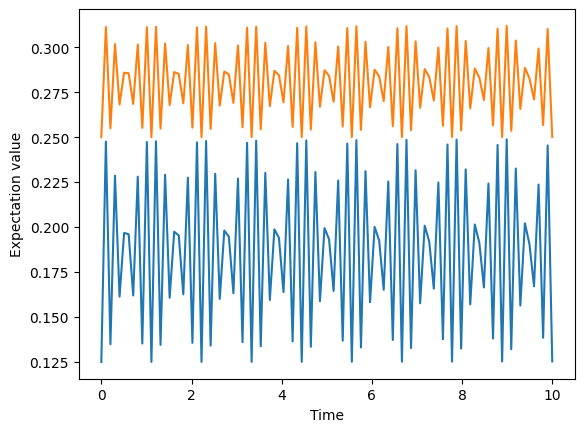

In [24]:
plt.plot(result2.times, result2.expect[0]*re, result3.times, result3.expect[0])
plt.xlabel('Time')
plt.ylabel('Expectation value')

In [25]:
k1 = 0.5
k2 = 1
mn1 = tensor(bs1[1].proj(),I3,I3)
mn2 = tensor(I3,bs1[1].proj(),I3)
mn3 = tensor(I3,I3,bs1[1].proj())
ps1 = tensor(bs1[2].proj(),I3,I3)
ps2 = tensor(I3,bs1[2].proj(),I3)
ps3 = tensor(I3,I3,bs1[2].proj())
damage1 = n*(k1*mn1)/2
recovery1 = n*(k2*ps1)/2
damage2 = n*(k1*mn2)/2
recovery2 = n*(k2*ps2)/2
damage3 = n*(k1*mn3)/2
recovery3 = n*(k2*ps3)/2
H_eff = H_dd - damage1 - damage2 - damage3 - recovery1 - recovery2 - recovery3

In [26]:
times1 = np.linspace(0,10,5)

In [27]:
result5 = mesolve(H_eff, psi0, times, [], [])
result5.states

[Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.35355339j]
  [-0.35355339+0.j        ]
  [ 0.        +0.j        ]
  [-0.35355339+0.j        ]
  [ 0.        -0.35355339j]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [ 0.        +0.j        ]
  [-0.35355339+0.j        ]
  [ 0.        -0.35355339j]
  [ 0.        +0.j        ]
  [ 0.        -0.35355339j]
  [ 0.35355339+0.j        ]],
 Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.        +0.j        ]
  [ 0.        +0.j        ]
  

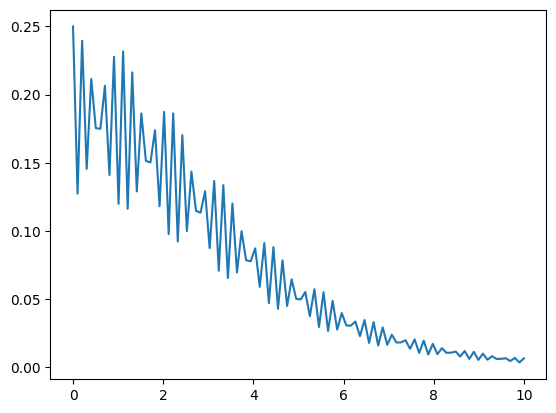

In [28]:
result7 = mesolve(H_eff, psi0, times, [], [(tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12))])
plt.plot(result7.times, result7.expect[0])
#print(result7.expect)

In [29]:
result6 = mesolve(H_dd, psi0, times1, [(ps1*mn1)/2], [])
#result6.states

In [30]:
sigma32 = bs1[2]*(bs1[1].dag())
sigma23 = bs1[1]*(bs1[2].dag())
sigma13 = bs1[0]*(bs1[2].dag())
sigma31 = bs1[2]*(bs1[0].dag())
#J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
#J1_32_psi = J1_32*(result5.states)
#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)

In [31]:
J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
J2_32 = tensor(I3,math.sqrt(k1)*sigma32,I3)
J3_32 = tensor(I3,I3,math.sqrt(k1)*sigma32)
J1_13 = tensor(math.sqrt(k2)*sigma13,I3,I3)
J2_13 = tensor(I3,math.sqrt(k2)*sigma13,I3)
J3_13 = tensor(I3,I3, math.sqrt(k2)*sigma13)
print(sigma32)

#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)
print(J2_13)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [32]:
delta_t = 0.0001

In [33]:
epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
print(epsilon)

0.36365419576416846


In [34]:
times_new = np.arange(0,70,delta_t)
print(times_new)


[0.00000e+00 1.00000e-04 2.00000e-04 ... 6.99997e+01 6.99998e+01
 6.99999e+01]


In [35]:
psi_updated = []
c = 0
c1 = 0
del_p = []
jump_where = []
jump_where1 = []
jump_which = []
psi_t = psi0
#psi_updated.append(psi_t)
for i in times_new :
  #psi_t = psi0
  expt = expect(H_eff-(H_eff.dag()),psi_t)
  delta_p = 1j*(delta_t*expt)
  epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
  #psi_updated.append(psi_t)
  if (delta_p.real < epsilon) :
    psi_dt = (1 - 1j*(H_eff*delta_t))*psi_t/(math.sqrt(1-delta_p.real))
    c = c+1
    psi_t = psi_dt
    psi_updated.append(psi_t)
  elif (delta_p.real >= epsilon) :
    c1 = c1 + 1
    jump_where.append(i)
    #kl.append(delta_p)
    #op.append(epsilon)
    delta = np.random.uniform(low = 0.0, high = 1.0, size = None)
    delta_p1_32 = (expect(J1_32.dag()*J1_32,psi_t))*delta_t
    delta_p2_32 = (expect(J2_32.dag()*J2_32,psi_t))*delta_t
    delta_p3_32 = (expect(J3_32.dag()*J3_32,psi_t))*delta_t
    delta_p1_13 = (expect(J1_13.dag()*J1_13,psi_t))*delta_t
    delta_p2_13 = (expect(J2_13.dag()*J2_13,psi_t))*delta_t
    delta_p3_13 = (expect(J3_13.dag()*J3_13,psi_t))*delta_t
    del_p = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count = np.count_nonzero(del_p, axis=None)
    ab = np.linspace(0,1,count+1)
    zero_where = np.where(del_p != 0)[0]
    prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for l in range(count) :
      if (delta >= ab[l] and delta < ab[l+1]) :
        psi_dt = ((J[zero_where[l]])*psi_t)/(cmath.sqrt(del_p[zero_where[l]]/delta_t))
        jump_where1.append(ab[l])
        jump_which.append(J[zero_where[l]])
        break
    psi_t = psi_dt
    psi_updated.append(psi_t)
    #psi_t = psi0
  #psi_t = psi_dt
  #psi_updated.append(psi_t)


In [36]:
#print(kl)
#print(op)
print(c)
print(c1)

699994
6


In [37]:
print(jump_which)

[Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.         0.         0.         0.70710678 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.70710678 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.70710678
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.     

In [38]:
print(jump_where)
print(expect(tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12),psi_updated[46020]))
#print(psi_updated[12832],psi_updated[12833],psi_updated[12834],psi_updated[16372],psi_updated[16373])

[np.float64(5.2297), np.float64(6.8787), np.float64(6.9343), np.float64(7.204400000000001), np.float64(7.3899), np.float64(7.4614)]
(0.0708701115938946+0j)


(0.0, 10.0)

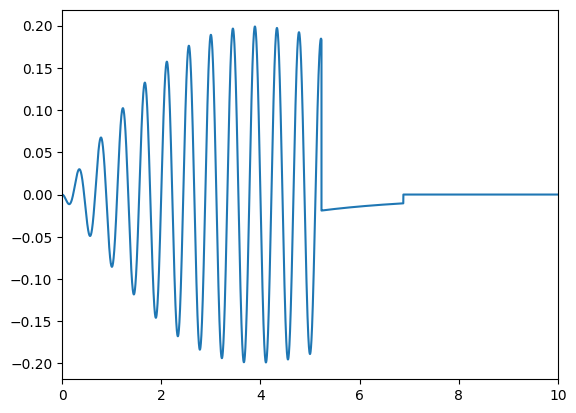

In [39]:
expectation2 = expect(tensor(sigma12,I3,I3),psi_updated)
plt.plot(times_new, expectation2)
plt.xlim([0,10])

(0.0, 10.0)

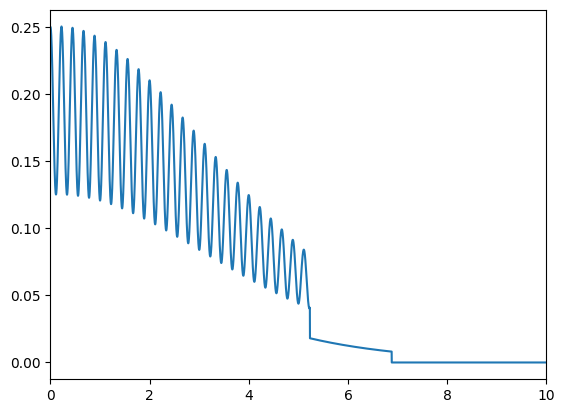

In [40]:
expectation3 = expect((tensor(sigma12,I3,I3)*tensor(I3,I3,sigma21)),psi_updated)
plt.plot(times_new, expectation3)
plt.xlim([0,10])

In [41]:
jump = np.zeros(700000)
for iter in range(6) :
  for iter1 in range(6) :
    if ((jump_which[iter] == J[iter1]) and (iter1 < 3)) :
      bn = int(jump_where[iter]*10000)
      bn_count = jump[bn]
      jump[bn:]+= 1
      break
    elif ((jump_which[iter] == J[iter1]) and (iter1 >= 3)) :
      cn = int(jump_where[iter]*10000)
      jump[cn:]-= 1
      break

print(jump)



[0. 0. 0. ... 0. 0. 0.]


(0.0, 15.0)

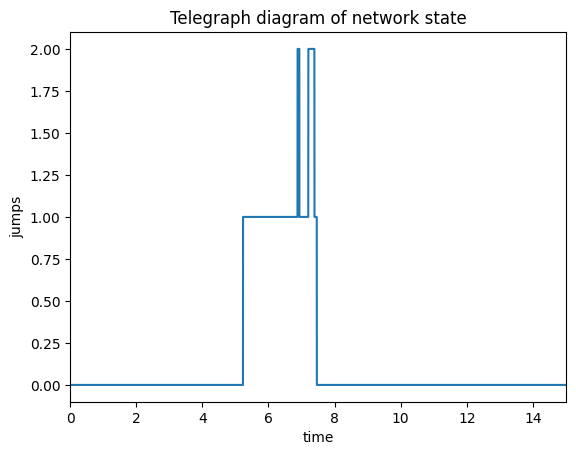

In [42]:
plt.plot(times_new, jump)
plt.xlabel('time')
plt.ylabel('jumps')
plt.title("Telegraph diagram of network state")
plt.xlim([0,15])

In [43]:
state1 = np.zeros(700000)
state2 = np.zeros(700000)
state3 = np.zeros(700000)
for i in range(6) :
  if (jump_which[i] == J[0] or jump_which[i] == J[3]) :
    bn = int(jump_where[i]*10000)
    state1[bn]+= 1
  elif (jump_which[i] == J[1] or jump_which[i] == J[4]) :
    bn = int(jump_where[i]*10000)
    state2[bn]+= 1
  else :
    bn = int(jump_where[i]*10000)
    state3[bn]+= 1


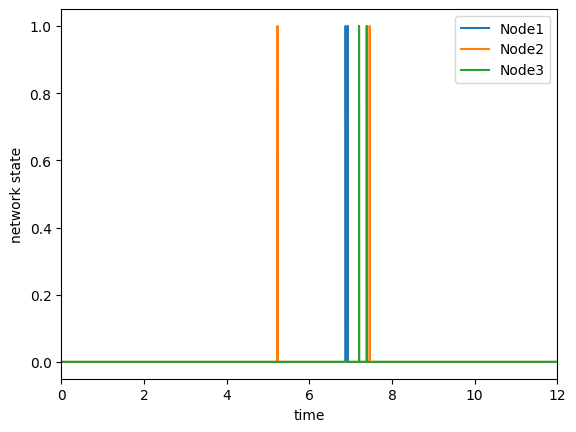

In [44]:
plt.plot(times_new, state1, times_new, state2, times_new, state3)
plt.xlabel('time')
plt.ylabel('network state')
#plt.title("Telegraph diagram of network state")
plt.xlim([0,12])
plt.legend(['Node1', 'Node2', 'Node3'])

(0.0, 5.0)

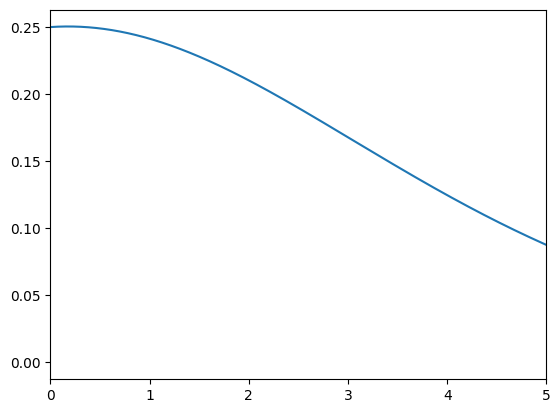

In [45]:
expectation1 = expect((tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)),psi_updated)
plt.plot(times_new, expectation1)
plt.xlim([0,5])

In [46]:
print(tensor(sigma12+sigma21,I3,I3))

Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [47]:
#print(tensor(sigma12,I3,I3)+tensor(sigma21,I3,I3))
tensor(sigma12,I3,I3)+tensor(sigma21,I3,I3) == tensor(sigma12+sigma21,I3,I3)

True

In [48]:
times_new1 = np.arange(0,10,delta_t)

In [49]:
data = mcsolve(H_eff, psi0, times_new1, [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13], [tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12)])

10.0%. Run time:  68.21s. Est. time left: 00:00:10:13
20.0%. Run time: 139.52s. Est. time left: 00:00:09:18
30.0%. Run time: 209.38s. Est. time left: 00:00:08:08
40.0%. Run time: 279.64s. Est. time left: 00:00:06:59
50.0%. Run time: 348.10s. Est. time left: 00:00:05:48
60.0%. Run time: 417.43s. Est. time left: 00:00:04:38
70.0%. Run time: 485.33s. Est. time left: 00:00:03:27
80.0%. Run time: 552.92s. Est. time left: 00:00:02:18
90.0%. Run time: 619.97s. Est. time left: 00:00:01:08
100.0%. Run time: 687.52s. Est. time left: 00:00:00:00
Total run time: 688.74s


In [50]:
data1 = mcsolve(H_eff, psi0, times_new1, [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13], [tensor(sigma21,I3,I3)])

10.0%. Run time:  66.01s. Est. time left: 00:00:09:54
20.0%. Run time: 134.25s. Est. time left: 00:00:08:57
30.0%. Run time: 202.56s. Est. time left: 00:00:07:52
40.0%. Run time: 271.79s. Est. time left: 00:00:06:47
50.0%. Run time: 342.70s. Est. time left: 00:00:05:42
60.0%. Run time: 410.77s. Est. time left: 00:00:04:33
70.0%. Run time: 479.67s. Est. time left: 00:00:03:25
80.0%. Run time: 547.31s. Est. time left: 00:00:02:16
90.0%. Run time: 615.02s. Est. time left: 00:00:01:08
100.0%. Run time: 682.26s. Est. time left: 00:00:00:00
Total run time: 683.48s


Text(0, 0.5, 'Expectation values')

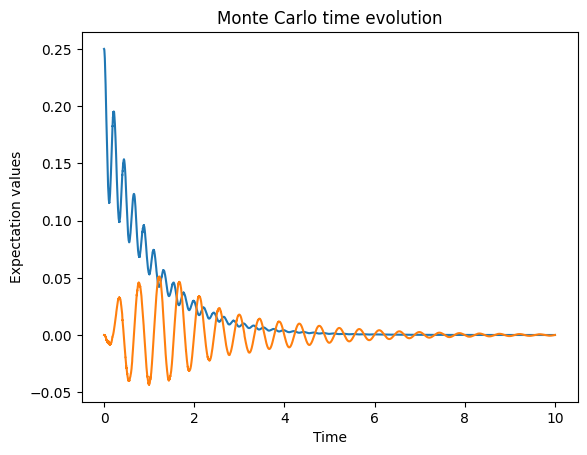

In [51]:
plt.plot(times_new1, data.expect[0], times_new1, data1.expect[0])
plt.title('Monte Carlo time evolution')
plt.xlabel('Time')
plt.ylabel('Expectation values')
#plt.xlim([0, 2])
#plt.legend(("cavity photon number", "atom excitation probability"))


In [52]:
ps = []
lk = []
nm = []
c2 = 0
psi_t1 = psi0
for u in times_new :
  #psi_t = psi0
  expt1 = expect(H_eff-(H_eff.dag()),psi_t1)
  delta_p1 = 1j*(delta_t*expt1)
  epsilon1 = np.random.uniform(low = 0.0, high = 0.000001)
  ps.append(psi_t1)
  lk.append(delta_p1)
  nm.append(epsilon1)
  if (delta_p1.real >= epsilon1) :
    c2 = c2 + 1
    delta1 = np.random.uniform(low = 0.0, high = 0.00001 , size = None)
    delta_p1_32 = -(expect(J1_32.dag()*J1_32,psi_t1))*delta_t
    delta_p2_32 = -(expect(J2_32.dag()*J2_32,psi_t1))*delta_t
    delta_p3_32 = -(expect(J3_32.dag()*J3_32,psi_t1))*delta_t
    delta_p1_13 = -(expect(J1_13.dag()*J1_13,psi_t1))*delta_t
    delta_p2_13 = -(expect(J2_13.dag()*J2_13,psi_t1))*delta_t
    delta_p3_13 = -(expect(J3_13.dag()*J3_13,psi_t1))*delta_t
    del_p1 = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J1 = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count1 = np.count_nonzero(del_p1, axis=None)
    ab1 = np.linspace(0,1,count1+1)
    zero_where1 = np.where(del_p1!= 0)[0]
    prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for s in range(count) :
      if (delta1 >= ab1[s] and delta1 < ab1[s+1]) :
        psi_dt1 = ((J1[zero_where1[s]])*psi_t1)/(cmath.sqrt(del_p1[zero_where1[s]]/delta_t))

    psi_t1 = psi_dt1

In [53]:
print(lk[:10])
print(nm[:10])

[(7.5e-05+0j), (0.00015000000000000001+0j), (0.00022500000000000002+0j), (0.00030000000000000003+0j), (0.0002+0j), (0.0001+0j), 0j, 0j, 0j, 0j]
[3.537946964638672e-08, 4.2432187787345186e-07, 3.450134239452266e-07, 9.969916678425175e-07, 8.655346219307497e-07, 4.6162192537619917e-07, 3.6290404853299916e-07, 2.607789324021752e-07, 6.660799865688843e-07, 7.423148621160126e-07]


In [54]:
print(c2)

6


In [55]:
#rl = psi_dt.real/(math.sqrt(1-delta_p))
    #im = psi_dt.imag/(math.sqrt(1-delta_p))
    #nm = psi_t.norm()

In [56]:
expt1 = expect((H_eff-(H_eff.dag())),psi0)
print(psi0.dag()*(H_eff-(H_eff.dag()))*psi0)
delta_p1 = 1j*(delta_t*expt1)
print(expt1,delta_p1)
epsilon = np.random.uniform(low = 0.0, high = 0.001, size = None)
print(epsilon)

-0.7499999999999999j
-0.7499999999999999j (7.5e-05+0j)
0.0006818079908607077


In [57]:
#print(expect(H_eff-H_eff.dag(),psi0))
print(c)
print(c1)
ty = (1 - 1j*H_eff*delta_t)*psi0
print(cmath.sqrt((ty.dag()*ty)[0]))
expt1 = expect(H_eff-H_eff.dag(),psi0)
delta_p1 = 1j*(delta_t*expt1)
print(cmath.sqrt(1-delta_p1).real)

699994
6


TypeError: 'complex' object is not subscriptable

In [58]:
print(psi_updated[10000:10500])


[Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.23271876j]
 [ 0.00213716+0.21342269j]
 [ 0.        +0.j        ]
 [ 0.00213716+0.42684538j]
 [-0.27405011+0.00260722j]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.00213716+0.21342269j]
 [-0.54810022+0.00260722j]
 [ 0.        +0.j        ]
 [-0.27405011+0.00260722j]
 [ 0.49271644+0.j        ]], Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.  

In [59]:
et = expect((tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)),psi_updated[11000])
print(et)
print(psi_updated[11000])

(0.23905897410394372-0.00671676498554777j)
Quantum object: dims=[[3, 3, 3], [1]], shape=(27, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.22216497j]
 [ 0.29243946+0.03113258j]
 [ 0.        +0.j        ]
 [ 0.29243946+0.06226515j]
 [-0.04109431+0.38499633j]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.29243946+0.03113258j]
 [-0.08218862+0.38499633j]
 [ 0.        +0.j        ]
 [-0.04109431+0.38499633j]
 [ 0.50700768+0.j        ]]


In [60]:
print(expectation[10500:11000])

NameError: name 'expectation' is not defined

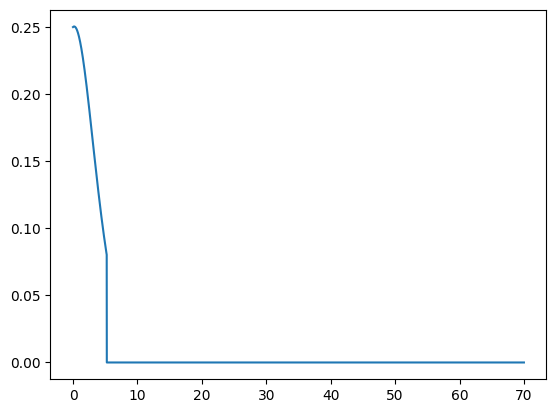

In [61]:
gh1 = expect((tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)),psi_updated)
#print(gh1*re)
plt.plot(times_new, gh1)
#plt.xlim([0, 0.1])
#plt.ylim([-1e-3, 1e-3])

In [62]:
for lk in range(count+1) :
      if (p>=ab[lk] and p<ab[lk+1]) :
        psi_dt = ((J[zero_where[lk]])*psi_t)/(cmath.sqrt(del_p[zero_where[lk]]/delta_t))

print(psi0)
print(psi_t)
print(psi_dt)
print(delta)
print(del_p)
print(del_p[zero_where[l]])

NameError: name 'p' is not defined

In [ ]:
zero_where = np.where(del_p != 0)[0]
m = zero_where[0]
#print(J[zero_where[1]])


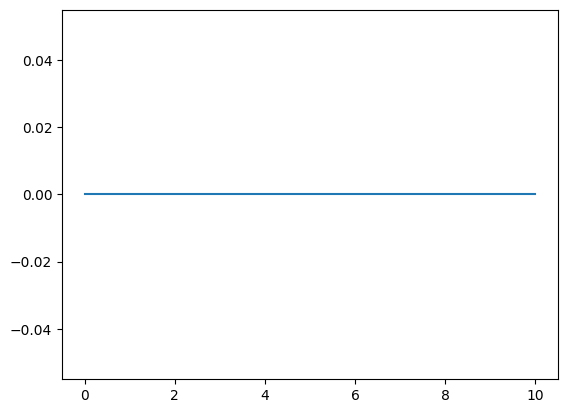

In [63]:
plt.plot(result7.times, result7.expect[0]*re)




In [64]:
psi_t = expect(H_eff-H_eff.dag(),psi0)
print(psi_t)

-0.7499999999999999j
